<a href="https://colab.research.google.com/github/R3beAM/Proyecto-Final-Integracion/blob/main/Evaluacion_2_Metodologia_corregida_Rebeca_Alvarez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

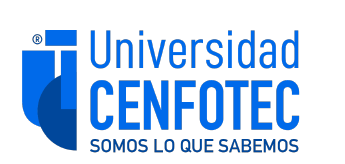

Estudiante: Rebeca Alvarez

Universidad CENFOTEC

Curso: Proyecto Integrador en IA

Nombre del Profesor a Cargo: Alexander Bermudez

Fecha: Mayo, 2026

#**Descripción del dataset original**

In [ ]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [ ]:
# Ruta al archivo (ajusta el nombre del archivo)
file_path = "/content/Amazon_Consumer_Review.csv"

# =========================
# 1. Cargar dataset
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DESCRIPCIÓN GENERAL DEL DATASET")
print("-" * 50)
print("Filas y columnas:", df.shape)
print("Cantidad de filas:", df.shape[0])
print("Cantidad de columnas:", df.shape[1])

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nPrimeras filas:")
display(df.head())

print("\nInformación general:")
df.info()

DESCRIPCIÓN GENERAL DEL DATASET
--------------------------------------------------
Filas y columnas: (28332, 24)
Cantidad de filas: 28332
Cantidad de columnas: 24

Columnas del dataset:
['id', 'dateAdded', 'dateUpdated', 'name', 'asins', 'brand', 'categories', 'primaryCategories', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'reviews.date', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.username', 'sourceURLs']

Primeras filas:


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doReco

##1. Resumen de tipos de variables

In [ ]:
# =========================
# 2. Tipos de variables
# =========================

tipos_variables = pd.DataFrame({
    "Variable": df.columns,
    "Tipo de dato": df.dtypes.astype(str),
    "Valores no nulos": df.notnull().sum().values,
    "Valores nulos": df.isnull().sum().values,
    "Porcentaje nulos": ((df.isnull().sum() / len(df)) * 100).round(2).values,
    "Valores únicos": df.nunique(dropna=False).values
})

display(tipos_variables)

,Variable,Tipo de dato,Valores no nulos,Valores nulos,Porcentaje nulos,Valores únicos
id,id,object,28332,0,0.00,65
dateAdded,dateAdded,object,28332,0,0.00,55
dateUpdated,dateUpdated,object,28332,0,0.00,52
name,name,object,28332,0,0.00,65
asins,asins,object,28332,0,0.00,65
brand,brand,object,28332,0,0.00,3
categories,categories,object,28332,0,0.00,60
primaryCategories,primaryCategories,object,28332,0,0.00,9
imageURLs,imageURLs,object,28332,0,0.00,65
keys,keys,object,28332,0,0.00,65


##Análisis de variables altamente correlacionadas

(Los problemas de cardinalidad alta, desbalance de clases y escalas inconsistentes se tomaron del avance anterior, y se documentaron en el documento de word)



In [ ]:
import pandas as pd

df = pd.read_csv("Amazon_Consumer_Review.csv")

# =========================
# 3. Crear variables numéricas auxiliares
# =========================

df["reviews.numHelpful"] = pd.to_numeric(df["reviews.numHelpful"], errors="coerce")

df["review_length_chars"] = df["reviews.text"].astype(str).apply(len)
df["review_length_words"] = df["reviews.text"].astype(str).apply(lambda x: len(x.split()))

# Variables numéricas disponibles
numeric_df = df.select_dtypes(include=["int64", "float64"])

print("Variables numéricas detectadas:")
print(numeric_df.columns.tolist())

# =========================
# 4. Matriz de correlación
# =========================

correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(3))

# =========================
# 5. Identificar correlaciones altas
# =========================

correlation_pairs = correlation_matrix.unstack().reset_index()
correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlación"]

# Eliminar correlación consigo misma
correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# Evitar duplicados
correlation_pairs["Par ordenado"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Par ordenado")
correlation_pairs = correlation_pairs.drop(columns=["Par ordenado"])

# Filtrar correlaciones fuertes
high_correlations = correlation_pairs[
    correlation_pairs["Correlación"].abs() >= 0.70
].sort_values(by="Correlación", ascending=False)

print("Variables altamente correlacionadas:")
display(high_correlations.round(3))

Variables numéricas detectadas:
['reviews.id', 'reviews.numHelpful', 'reviews.rating', 'review_length_chars', 'review_length_words']


,reviews.id,reviews.numHelpful,reviews.rating,review_length_chars,review_length_words
reviews.id,1.000,-0.554,0.075,-0.009,-0.016
reviews.numHelpful,-0.554,1.000,-0.041,0.237,0.233
reviews.rating,0.075,-0.041,1.000,-0.120,-0.120
review_length_chars,-0.009,0.237,-0.120,1.000,0.997
review_length_words,-0.016,0.233,-0.120,0.997,1.000


Variables altamente correlacionadas:


,Variable 1,Variable 2,Correlación
19,review_length_chars,review_length_words,0.997


In [ ]:
#Vamos a modificar la columna reviews.username a que sea string, para que pueda ser parte de las correlaciones
# Reemplazar nulos y convertir a texto
df["reviews.username"] = df["reviews.username"].fillna("unknown").astype("string")

# Verificar resultado
print(df["reviews.username"].dtype)
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# Convertir reviews.username a tipo texto/string
df["reviews.username"] = df["reviews.username"].astype("string")

# Verificar el tipo de dato
print(df["reviews.username"].dtype)

# Ver primeras filas
df[["reviews.username"]].head()

string


,reviews.username
0,Byger yang
1,ByMG
2,BySharon Lambert
3,Bymark sexson
4,Bylinda


In [ ]:
# =========================
# 6. Asociación entre variables de texto (Cramér's V + coincidencia + tablas cruzadas)
# =========================

from scipy.stats import chi2_contingency
import numpy as np
import itertools

text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")


def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)

print("Resumen de asociación entre variables categóricas:")
display(summary_df.sort_values("Cramér's V", ascending=False).round(4))

# Mostrar tablas cruzadas para revisar posibles réplicas
for r in results:
    print(f"\nTabla cruzada: {r['Variable 1']} vs {r['Variable 2']}")
    display(r["Tabla cruzada"])



Resumen de asociación entre variables categóricas:


,Variable 1,Variable 2,Cramér's V,% coincidencia
0,brand,manufacturer,0.7071,99.9188
1,brand,reviews.username,0.6524,0.0035
2,manufacturer,reviews.username,0.6129,0.0035



Tabla cruzada: brand vs manufacturer


manufacturer,Amazon,Amazon Digital Services,Amazon.com,AmazonBasics
brand,,,,
Amazon,16130,18,5,0
AmazonBasics,0,0,0,10
Amazonbasics,0,0,0,12169



Tabla cruzada: brand vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
brand,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazonbasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Tabla cruzada: manufacturer vs reviews.username


reviews.username,000G,00Gambler,1000011,10100915,1029cr,1098,118001,1191946,11bee,1215,...,zRoyals,zackeemom,zane1222,zedog83,zeke,zerosky,zetyk,ziggy24,zmax192,ztlbxx
manufacturer,,,,,,,,,,,,,,,,,,,,,
Amazon,2,2,2,2,3,2,2,2,1,1,...,2,1,3,2,4,2,1,3,3,1
Amazon Digital Services,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Amazon.com,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AmazonBasics,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Interpretación de los resultados**

Estos resultados analizan la asociación entre variables categóricas usando Cramér’s V y porcentaje de coincidencia. En general, muestran que existe una relación fuerte entre brand y manufacturer, mientras que las asociaciones con reviews.username deben interpretarse con mucha cautela por su alta cardinalidad.

1. Asociación entre brand y manufacturer

| Variable 1 | Variable 2     | Cramér’s V | % coincidencia |
| ---------- | -------------- | ---------: | -------------: |
| `brand`    | `manufacturer` |     0.7071 |       99.9188% |


El valor de Cramér’s V = 0.7071 indica una asociación alta entre brand y manufacturer.

Además, el porcentaje de coincidencia es de 99.9188%, lo cual significa que ambas variables contienen prácticamente la misma información en casi todos los registros.

La tabla cruzada confirma esto:

| brand        | Amazon | Amazon Digital Services | Amazon.com | AmazonBasics |
| ------------ | -----: | ----------------------: | ---------: | -----------: |
| Amazon       |  16130 |                      18 |          5 |            0 |
| AmazonBasics |      0 |                       0 |          0 |           10 |
| Amazonbasics |      0 |                       0 |          0 |        12169 |


La mayoría de registros con brand = Amazon tienen manufacturer = Amazon. De igual forma, brand = Amazonbasics se asocia casi completamente con manufacturer = AmazonBasics.

Conclusión

brand y manufacturer son variables altamente redundantes.

Para el modelo, no es necesario usar ambas. Se recomienda conservar solo una para evitar duplicidad de información.

Para mi modelo, conservaré brand, porque es más clara desde el punto de vista de negocio y suele representar mejor la identidad comercial del producto.

También conviene normalizar valores como:

AmazonBasics
Amazonbasics

porque representan probablemente la misma marca, pero están escritos con diferente capitalización.

2. Asociación entre brand y reviews.username

| Variable 1 | Variable 2         | Cramér’s V | % coincidencia |
| ---------- | ------------------ | ---------: | -------------: |
| `brand`    | `reviews.username` |     0.6524 |        0.0035% |


A primera vista, Cramér’s V = 0.6524 parece indicar una asociación moderada-alta. Sin embargo, el porcentaje de coincidencia es prácticamente cero: 0.0035%.

Esto ocurre porque reviews.username tiene una cardinalidad extremadamente alta: la tabla muestra 16,269 columnas, una por cada usuario.

Cuando una variable categórica tiene muchísimos valores únicos, Cramér’s V puede dar una impresión inflada de asociación, especialmente si muchos usuarios aparecen pocas veces o solo asociados a una marca por casualidad.

En otras palabras, la asociación no necesariamente significa que el usuario explique la marca o que sea útil para el modelo. Puede ser un efecto estadístico causado por la alta cardinalidad.

Conclusión

reviews.username no debe considerarse una variable útil para el modelo.

Aunque Cramér’s V parece alto, la variable tiene demasiadas categorías, baja generalización y puede introducir ruido.

En mi modelo voy a excluir reviews.username del modelo predictivo.

Razones:

alta cardinalidad;
poco valor predictivo generalizable;
riesgo de sobreajuste;
posible problema de privacidad;
no aporta lógica de negocio directa para predecir caída en desempeño.

3. Asociación entre manufacturer y reviews.username

| Variable 1     | Variable 2         | Cramér’s V | % coincidencia |
| -------------- | ------------------ | ---------: | -------------: |
| `manufacturer` | `reviews.username` |     0.6129 |        0.0035% |


Interpretación

El caso es similar al anterior. El valor de Cramér’s V = 0.6129 puede parecer alto, pero está influenciado por la alta cardinalidad de reviews.username.

La tabla cruzada muestra muchísimos usuarios, y casi todos se concentran bajo manufacturer = Amazon, porque el dataset está dominado por productos de Amazon.

Esto no significa que reviews.username sea una buena variable predictiva. Significa más bien que muchos usuarios aparecen en un dataset donde casi todos los productos pertenecen a Amazon o AmazonBasics.

Conclusión

La asociación entre manufacturer y reviews.username no debe usarse como argumento para conservar reviews.username.

La relación es poco útil desde el punto de vista predictivo y puede generar sobreajuste.

4. Hallazgos principales

| Hallazgo                                              | Interpretación                       | Decisión recomendada               |
| ----------------------------------------------------- | ------------------------------------ | ---------------------------------- |
| `brand` y `manufacturer` están altamente asociados    | Contienen información casi duplicada | Conservar solo una                 |
| `brand` y `manufacturer` tienen 99.9% de coincidencia | Son variables redundantes            | Preferir `brand`                   |
| `reviews.username` tiene cardinalidad extrema         | Más de 16,000 usuarios únicos        | Excluir del modelo                 |
| Cramér’s V con `reviews.username` parece alto         | Puede estar inflado por cardinalidad | No interpretarlo como señal fuerte |
| `AmazonBasics` y `Amazonbasics` aparecen separados    | Problema de consistencia textual     | Estandarizar capitalización        |


5. Implicación para mi modelo

Si incluye brand, manufacturer y reviews.username al mismo tiempo, puede generar:

redundancia;
demasiadas columnas por One-Hot Encoding;
sobreajuste;
baja interpretabilidad;
aumento innecesario de dimensionalidad.

La Regresión Logística asigna un coeficiente a cada variable. Si se incluyen variables redundantes, como brand y manufacturer, los coeficientes pueden volverse menos estables. Si se incluye reviews.username, el modelo puede aprender patrones específicos de usuarios que no se repiten en nuevos datos.

6. Decisión final

| Variable           | Decisión  | Justificación                                             |
| ------------------ | --------- | --------------------------------------------------------- |
| `brand`            | Conservar | Clara, interpretable y útil para segmentación.            |
| `manufacturer`     | Eliminar  | Redundante con `brand`.                                   |
| `reviews.username` | Eliminar  | Alta cardinalidad, riesgo de sobreajuste y baja utilidad. |
.


#Graficos de visualización

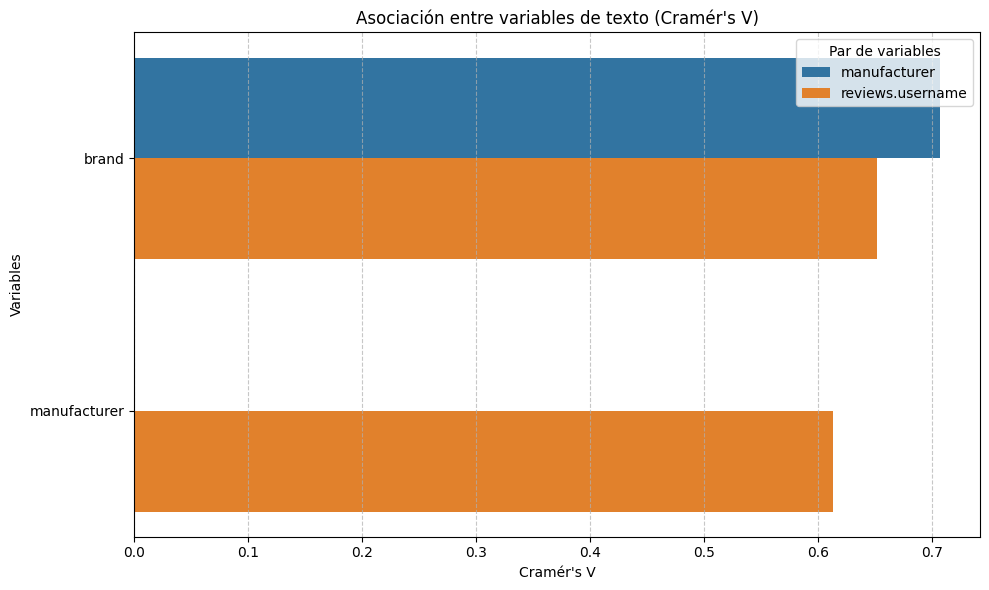

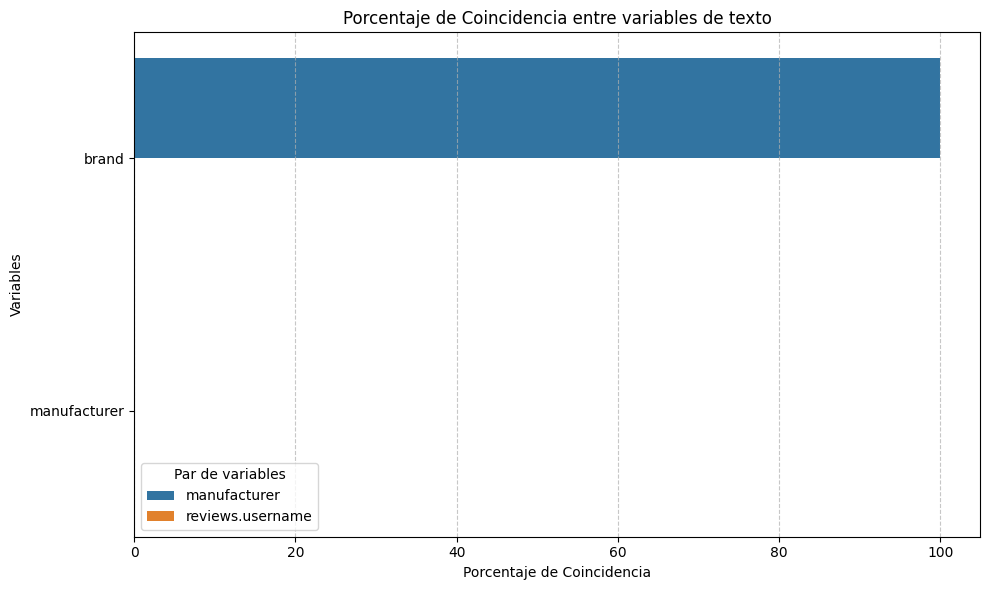

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np
import itertools

# --- Code to define summary_df ---
text_cols = ["brand", "manufacturer", "reviews.username"]

# Asegurar columnas como texto y sin nulos
for col in text_cols:
    df[col] = df[col].fillna("missing").astype("string")

def cramers_v(x, y):
    """Calcula Cramér's V con corrección de sesgo de Bergsma/Wicher."""
    contingency = pd.crosstab(x, y)

    if contingency.empty:
        return np.nan

    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()

    if n == 0:
        return np.nan

    phi2 = chi2 / n
    r, k = contingency.shape

    # Corrección por sesgo
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denom = min((kcorr - 1), (rcorr - 1))
    if denom <= 0:
        return np.nan

    return np.sqrt(phi2corr / denom)


results = []
for a, b in itertools.combinations(text_cols, 2):
    pair_df = df[[a, b]].dropna()

    # Cramér's V
    c_v = cramers_v(pair_df[a], pair_df[b])

    # % de coincidencia exacta (útil especialmente para brand vs manufacturer)
    match_pct = (pair_df[a].str.lower().str.strip() == pair_df[b].str.lower().str.strip()).mean() * 100

    # Tabla cruzada (not strictly needed for summary_df, but part of original logic)
    ctab = pd.crosstab(pair_df[a], pair_df[b])

    results.append(
        {
            "Variable 1": a,
            "Variable 2": b,
            "Cramér's V": c_v,
            "% coincidencia": match_pct,
            "Tabla cruzada": ctab,
        }
    )

# Resumen numérico
summary_df = pd.DataFrame(
    [
        {
            "Variable 1": r["Variable 1"],
            "Variable 2": r["Variable 2"],
            "Cramér's V": r["Cramér's V"],
            "% coincidencia": r["% coincidencia"],
        }
        for r in results
    ]
)
# --- End of code to define summary_df ---

# =========================
# 6.1. Visualización de Cramér's V
# =========================

plt.figure(figsize=(10, 6))
sns.barplot(x="Cramér's V", y="Variable 1", hue="Variable 2", data=summary_df.sort_values("Cramér's V", ascending=False))
plt.title("Asociación entre variables de texto (Cramér's V)")
plt.xlabel("Cramér's V")
plt.ylabel("Variables")
plt.legend(title="Par de variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =========================
# 6.2. Visualización de % coincidencia
# =========================

plt.figure(figsize=(10, 6))
sns.barplot(x="% coincidencia", y="Variable 1", hue="Variable 2", data=summary_df.sort_values("% coincidencia", ascending=False))
plt.title("Porcentaje de Coincidencia entre variables de texto")
plt.xlabel("Porcentaje de Coincidencia")
plt.ylabel("Variables")
plt.legend(title="Par de variables")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Conclusion final

El dataset original es adecuado para analizar patrones de reseñas negativas y construir indicadores de riesgo asociados al desempeño de productos. Contiene texto, ratings, fechas, productos y categorías, lo cual permite generar variables útiles para evaluar la percepción del consumidor.
Sin embargo, el dataset tiene una limitación fundamental: no incluye datos reales de ventas. Por lo tanto, el proyecto no podrá predecir una caída de ventas en sentido estricto, sino un riesgo de caída de ventas basado en señales indirectas de insatisfacción del cliente.
Los principales problemas identificados son el desbalance de clases, la alta concentración de reseñas positivas, la presencia de variables con muchos nulos, la alta cardinalidad en variables de producto y usuario, variables potencialmente redundantes y escalas inconsistentes entre variables numéricas.
A pesar de estas limitaciones, el dataset es utilizable si se redefine correctamente el problema como una predicción de riesgo. Para ello, será necesario construir variables agregadas por producto y periodo, identificar reseñas negativas, analizar cambios en el rating promedio y usar modelos capaces de detectar patrones asociados a deterioro en la percepción del producto.


#**Ingeniería de características estándar**

A continuación presentaré 3 propuestas en Python, dependientes entre sí para crear features estándar usando su dataset de reseñas de Amazon, adaptado al nuevo enfoque: predecir riesgo de caída de ventas de un producto con base en reseñas negativas.


Limpieza inicial

In [ ]:
import pandas as pd
import numpy as np

# =========================
# 1. Cargar dataset original
# =========================

df = pd.read_csv("Amazon_Consumer_Review.csv")

print("DATASET ORIGINAL")
print("Shape:", df.shape)
display(df.head())

# =========================
# 2. Limpieza inicial
# =========================

# Convertir fechas
df["reviews.date"] = pd.to_datetime(df["reviews.date"], errors="coerce")

# Convertir numHelpful a numérica
df["reviews.numHelpful"] = pd.to_numeric(
    df["reviews.numHelpful"],
    errors="coerce"
).fillna(0)

# Eliminar columnas con demasiados nulos, si existen
columnas_eliminar = ["reviews.didPurchase", "reviews.id"]

df = df.drop(
    columns=[col for col in columnas_eliminar if col in df.columns],
    errors="ignore"
)

# =========================
# 3. Features básicas por reseña
# =========================

# Texto combinado
df["review_full_text"] = (
    df["reviews.title"].astype(str) + " " + df["reviews.text"].astype(str)
)

# Longitud del texto
df["review_length_chars"] = df["review_full_text"].apply(len)
df["review_length_words"] = df["review_full_text"].apply(lambda x: len(x.split()))

# Variables temporales
df["review_year"] = df["reviews.date"].dt.year
df["review_month"] = df["reviews.date"].dt.month
df["review_quarter"] = df["reviews.date"].dt.quarter
df["year_month"] = df["reviews.date"].dt.to_period("M").astype(str)

# Variables binarias de satisfacción
df["is_negative_review"] = np.where(df["reviews.rating"] <= 2, 1, 0)
df["is_neutral_review"] = np.where(df["reviews.rating"] == 3, 1, 0)
df["is_positive_review"] = np.where(df["reviews.rating"] >= 4, 1, 0)

# Variable de no recomendación
df["not_recommended"] = np.where(df["reviews.doRecommend"] == False, 1, 0)

print("DESPUÉS DE FEATURES POR RESEÑA")
print("Shape:", df.shape)
display(df[[
    "name",
    "reviews.rating",
    "reviews.date",
    "review_length_words",
    "is_negative_review",
    "not_recommended",
    "year_month"
]].head())

DATASET ORIGINAL
Shape: (28332, 24)


,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


DESPUÉS DE FEATURES POR RESEÑA
Shape: (28332, 33)


/tmp/ipykernel_887/398291734.py:52: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["reviews.date"].dt.to_period("M").astype(str)


,name,reviews.rating,reviews.date,review_length_words,is_negative_review,not_recommended,year_month
0,AmazonBasics AAA Performance Alkaline Batterie...,3,2017-03-02 00:00:00+00:00,51,0,0,2017-03
1,AmazonBasics AAA Performance Alkaline Batterie...,4,2016-08-31 00:00:00+00:00,24,0,0,2016-08
2,AmazonBasics AAA Performance Alkaline Batterie...,5,2016-12-06 00:00:00+00:00,23,0,0,2016-12
3,AmazonBasics AAA Performance Alkaline Batterie...,5,2016-03-28 00:00:00+00:00,25,0,0,2016-03
4,AmazonBasics AAA Performance Alkaline Batterie...,5,2017-04-22 00:00:00+00:00,20,0,0,2017-04


##Propuesta 1. Features agregadas por producto

In [ ]:
product_features = df.groupby("name").agg(
    total_reviews=("reviews.rating", "count"),
    avg_rating=("reviews.rating", "mean"),
    min_rating=("reviews.rating", "min"),
    max_rating=("reviews.rating", "max"),
    negative_reviews=("is_negative_review", "sum"),
    neutral_reviews=("is_neutral_review", "sum"),
    positive_reviews=("is_positive_review", "sum"),
    not_recommended_count=("not_recommended", "sum"),
    avg_helpful_votes=("reviews.numHelpful", "mean"),
    total_helpful_votes=("reviews.numHelpful", "sum"),
    avg_review_length_words=("review_length_words", "mean"),
    first_review_date=("reviews.date", "min"),
    last_review_date=("reviews.date", "max")
).reset_index()

# =========================
# Añadir Brand y Primary Categories a product_features
# =========================
# Estas columnas son atributos a nivel de producto.
product_brand_category = df[['name', 'brand', 'primaryCategories']].drop_duplicates(subset=['name'])

# Fusionar con product_features
product_features = product_features.merge(
    product_brand_category,
    on='name',
    how='left'
)

# Ratios por producto
product_features["negative_review_rate"] = (
    product_features["negative_reviews"] / product_features["total_reviews"]
)

product_features["positive_review_rate"] = (
    product_features["positive_reviews"] / product_features["total_reviews"]
)

product_features["not_recommended_rate"] = (
    product_features["not_recommended_count"] / product_features["total_reviews"]
)

# Antigüedad en días
product_features["review_period_days"] = (
    product_features["last_review_date"] - product_features["first_review_date"]
).dt.days

# Frecuencia de reseñas
product_features["review_frequency"] = (
    product_features["total_reviews"] /
    product_features["review_period_days"].replace(0, np.nan)
)

print("FEATURES POR PRODUCTO")
print("Shape:", product_features.shape)
display(product_features.head())

FEATURES POR PRODUCTO
Shape: (65, 21)


,name,total_reviews,avg_rating,min_rating,max_rating,negative_reviews,neutral_reviews,positive_reviews,not_recommended_count,avg_helpful_votes,...,avg_review_length_words,first_review_date,last_review_date,brand,primaryCategories,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",82,4.585366,1,5,2,2,78,3,0.573171,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.024390,0.951220,0.036585,308.0,0.266234
1,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",233,4.630901,1,5,9,10,214,12,0.454936,...,41.000000,2017-06-15 00:00:00+00:00,2018-09-10 00:32:46+00:00,Amazon,Electronics,0.038627,0.918455,0.051502,452.0,0.515487
2,"All-New Fire HD 8 Kids Edition Tablet, 8 HD Di...",293,4.641638,1,5,6,11,276,9,0.313993,...,34.044369,2017-06-21 00:00:00+00:00,2018-05-25 00:00:00+00:00,Amazon,Electronics,0.020478,0.941980,0.030717,338.0,0.866864
3,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",883,4.578709,1,5,15,45,823,34,0.285391,...,31.682899,2017-06-20 00:00:00+00:00,2018-05-26 00:00:00+00:00,Amazon,Electronics,0.016988,0.932050,0.038505,340.0,2.597059
4,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",160,4.600000,1,5,5,2,153,9,0.731250,...,35.906250,2017-06-07 00:00:00+00:00,2018-05-22 00:00:00+00:00,Amazon,Electronics,0.031250,0.956250,0.056250,349.0,0.458453


##Propuesta 2: Features temporales producto-mes

In [ ]:
monthly_product = df.groupby(["name", "year_month"]).agg(
    monthly_reviews=("reviews.rating", "count"),
    monthly_avg_rating=("reviews.rating", "mean"),
    monthly_negative_reviews=("is_negative_review", "sum"),
    monthly_positive_reviews=("is_positive_review", "sum"),
    monthly_not_recommended=("not_recommended", "sum"),
    monthly_avg_helpful=("reviews.numHelpful", "mean"),
    monthly_avg_length_words=("review_length_words", "mean")
).reset_index()

# =========================
# 3. Añadir Brand y Primary Categories
# =========================
# Estas variables son a nivel de producto y se pueden añadir directamente.
monthly_product = monthly_product.merge(
    product_features[['name', 'brand', 'primaryCategories']],
    on='name',
    how='left'
)

# Ratios mensuales
monthly_product["monthly_negative_rate"] = (
    monthly_product["monthly_negative_reviews"] / monthly_product["monthly_reviews"]
)

monthly_product["monthly_positive_rate"] = (
    monthly_product["monthly_positive_reviews"] / monthly_product["monthly_reviews"]
)

monthly_product["monthly_not_recommended_rate"] = (
    monthly_product["monthly_not_recommended"] / monthly_product["monthly_reviews"]
)

# Orden temporal
monthly_product["year_month_date"] = pd.to_datetime(monthly_product["year_month"])
monthly_product = monthly_product.sort_values(["name", "year_month_date"])

# Lags
monthly_product["prev_month_avg_rating"] = (
    monthly_product.groupby("name")["monthly_avg_rating"].shift(1)
)

monthly_product["prev_month_negative_rate"] = (
    monthly_product.groupby("name")["monthly_negative_rate"].shift(1)
)

# Diferencias
monthly_product["rating_change"] = (
    monthly_product["monthly_avg_rating"] - monthly_product["prev_month_avg_rating"]
)

monthly_product["negative_rate_change"] = (
    monthly_product["monthly_negative_rate"] - monthly_product["prev_month_negative_rate"]
)

# Rolling windows de 3 meses
monthly_product["rolling_3m_avg_rating"] = (
    monthly_product.groupby("name")["monthly_avg_rating"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

monthly_product["rolling_3m_negative_rate"] = (
    monthly_product.groupby("name")["monthly_negative_rate"]
    .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

print("FEATURES PRODUCTO-MES")
print("Shape:", monthly_product.shape)
display(monthly_product.head(10))

/tmp/ipykernel_887/1678113537.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  monthly_product["year_month_date"] = pd.to_datetime(monthly_product["year_month"])


FEATURES PRODUCTO-MES
Shape: (561, 21)


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand,...,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,year_month_date,prev_month_avg_rating,prev_month_negative_rate,rating_change,negative_rate_change,rolling_3m_avg_rating,rolling_3m_negative_rate
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,0.00000,1.000000,0.000000,2017-06-01,NaN,NaN,NaN,NaN,5.000000,0.00000
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,0.00000,1.000000,0.000000,2017-07-01,5.000000,0.00000,-0.400000,0.00000,4.800000,0.00000
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,0.00000,0.888889,0.111111,2017-08-01,4.600000,0.00000,-0.377778,0.00000,4.607407,0.00000
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,0.00000,1.000000,0.000000,2017-09-01,4.222222,0.00000,0.444444,0.00000,4.496296,0.00000
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,0.00000,1.000000,0.000000,2017-10-01,4.666667,0.00000,0.333333,0.00000,4.629630,0.00000
5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-12,41,4.634146,2,39,2,0.000000,22.097561,Amazon,...,0.04878,0.951220,0.048780,2017-12-01,5.000000,0.00000,-0.365854,0.04878,4.766938,0.01626
6,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-01,11,4.545455,0,11,0,0.000000,22.636364,Amazon,...,0.00000,1.000000,0.000000,2018-01-01,4.634146,0.04878,-0.088692,-0.04878,4.726534,0.01626
7,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-02,5,4.800000,0,5,0,0.000000,26.600000,Amazon,...,0.00000,1.000000,0.000000,2018-02-01,4.545455,0.00000,0.254545,0.00000,4.659867,0.01626
8,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-03,4,4.250000,0,3,0,0.000000,31.500000,Amazon,...,0.00000,0.750000,0.000000,2018-03-01,4.800000,0.00000,-0.550000,0.00000,4.531818,0.00000
9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-04,2,5.000000,0,2,0,0.000000,15.000000,Amazon,...,0.00000,1.000000,0.000000,2018-04-01,4.250000,0.00000,0.750000,0.00000,4.683333,0.00000


##Propuesta 3: Combinar features de producto con producto-mes

In [ ]:
final_dataset = monthly_product.merge(
    product_features,
    on="name",
    how="left"
)

print("DATASET FINAL COMBINADO")
print("Shape:", final_dataset.shape)
print("Columnas:", final_dataset.columns.tolist())
display(final_dataset.head())

DATASET FINAL COMBINADO
Shape: (561, 41)
Columnas: ['name', 'year_month', 'monthly_reviews', 'monthly_avg_rating', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'brand_x', 'primaryCategories_x', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'year_month_date', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rating_change', 'negative_rate_change', 'rolling_3m_avg_rating', 'rolling_3m_negative_rate', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'first_review_date', 'last_review_date', 'brand_y', 'primaryCategories_y', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency']


,name,year_month,monthly_reviews,monthly_avg_rating,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,...,avg_review_length_words,first_review_date,last_review_date,brand_y,primaryCategories_y,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,5.000000,0,1,0,44.000000,102.000000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,4.600000,0,5,0,0.200000,45.400000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,4.222222,0,8,1,0.222222,28.555556,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,4.666667,0,3,0,0.000000,21.666667,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,5.000000,0,1,0,0.000000,25.000000,Amazon,...,25.853659,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234


##Crear variable proxy de riesgo

Como el dataset no tiene ventas reales, se crea una variable proxy llamada sales_drop_risk.

In [ ]:
import pandas as pd # Ensure pandas is imported for DataFrame operations
import numpy as np # Ensure numpy is imported for np.where

try:
    # Check if monthly_avg_rating and monthly_negative_rate are in final_dataset.
    # If not, merge them back from monthly_product (assuming monthly_product is correctly defined upstream).
    if 'monthly_avg_rating' not in final_dataset.columns or 'monthly_negative_rate' not in final_dataset.columns:
        print("Warning: 'monthly_avg_rating' or 'monthly_negative_rate' missing from final_dataset. Attempting to merge from monthly_product.")
        # Need to ensure 'monthly_product' is available and correctly structured

        if 'monthly_product' not in locals() and 'monthly_product' not in globals():
            raise NameError("La variable 'monthly_product' no está definida. Asegúrate de ejecutar la celda '_ikbmSUDyyXS'.")

        # Ensure final_dataset is sorted before any merge for consistent results
        final_dataset = final_dataset.sort_values(by=['name', 'year_month']).reset_index(drop=True)

        # Merge monthly_avg_rating if missing
        if 'monthly_avg_rating' not in final_dataset.columns:
            final_dataset = pd.merge(
                final_dataset,
                monthly_product[['name', 'year_month', 'monthly_avg_rating']],
                on=['name', 'year_month'],
                how='left'
            )
            print("Merged 'monthly_avg_rating' from monthly_product.")

        # Merge monthly_negative_rate if missing
        if 'monthly_negative_rate' not in final_dataset.columns:
            final_dataset = pd.merge(
                final_dataset,
                monthly_product[['name', 'year_month', 'monthly_negative_rate']],
                on=['name', 'year_month'],
                how='left'
            )
            print("Merged 'monthly_negative_rate' from monthly_product.")

    # Re-calculate 'rating_change' and 'negative_rate_change' based on current and previous month's values.
    # These calculations now rely on 'monthly_avg_rating' and 'monthly_negative_rate' which are ensured to be present.

    # Ensure sorting for correct shift/diff operations
    final_dataset = final_dataset.sort_values(by=['name', 'year_month']).reset_index(drop=True)

    # Re-calculate rating_change (diff between current monthly_avg_rating and previous month's monthly_avg_rating)
    # We re-calculate unconditionally to ensure correctness, as its presence earlier might have been flawed.
    final_dataset['rating_change'] = final_dataset.groupby('name')['monthly_avg_rating'].diff(1)

    # Re-calculate negative_rate_change (diff between current monthly_negative_rate and previous month's monthly_negative_rate)
    final_dataset['negative_rate_change'] = final_dataset.groupby('name')['monthly_negative_rate'].diff(1)

    # Re-calculate rolling_3m_negative_rate
    final_dataset['rolling_3m_negative_rate'] = (
        final_dataset.groupby('name')['monthly_negative_rate']
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    # Now create lagged versions of the features that will define the target for the CURRENT month.
    # The target for a given row (month M) is defined by values from the previous month (M-1).
    final_dataset['prev_rating_change_for_target'] = final_dataset.groupby('name')['rating_change'].shift(1)
    final_dataset['prev_negative_rate_change_for_target'] = final_dataset.groupby('name')['negative_rate_change'].shift(1)
    final_dataset['prev_rolling_3m_negative_rate_for_target'] = final_dataset.groupby('name')['rolling_3m_negative_rate'].shift(1)
    final_dataset['prev_monthly_avg_rating_for_target'] = final_dataset.groupby('name')['monthly_avg_rating'].shift(1)

    # Define sales_drop_risk for the current month based on previous month's metrics
    final_dataset["sales_drop_risk"] = np.where(
        (
            (final_dataset["prev_rating_change_for_target"] <= -0.5) |
            (final_dataset["prev_negative_rate_change_for_target"] >= 0.10) |
            (final_dataset["prev_rolling_3m_negative_rate_for_target"] >= 0.15) |
            (final_dataset["prev_monthly_avg_rating_for_target"] < 4.0)
        ),
        1,
        0
    )

    # Identify all columns used to create 'sales_drop_risk' (both current and lagged versions)
    # These columns must be dropped to prevent data leakage.
    leakage_cols_for_drop = [
        "rating_change",
        "negative_rate_change",
        "rolling_3m_negative_rate",
        "monthly_avg_rating", # This is the current month's average rating
        "prev_rating_change_for_target",
        "prev_negative_rate_change_for_target",
        "prev_rolling_3m_negative_rate_for_target",
        "prev_monthly_avg_rating_for_target"
    ]

    # Drop these columns from final_dataset to prevent data leakage in subsequent modeling steps
    # Ensure we only try to drop columns that actually exist.
    final_dataset = final_dataset.drop(columns=[col for col in leakage_cols_for_drop if col in final_dataset.columns], errors='ignore')

    print("DISTRIBUCIÓN DEL TARGET")
    display(final_dataset["sales_drop_risk"].value_counts())
    display((final_dataset["sales_drop_risk"].value_counts(normalize=True) * 100).round(2))

    display(final_dataset[[
        "name",
        "year_month",
        "monthly_reviews",
        "monthly_negative_rate",
        "sales_drop_risk"
    ]].head(15))

except NameError as e:
    if "final_dataset" in str(e):
        print("Error: La variable 'final_dataset' no está definida.")
        print("Asegúrate de ejecutar todas las celdas anteriores que crean y procesan 'final_dataset', incluyendo la celda 'NBjhxQRczQod' y las celdas de preprocesamiento posteriores.")
        print(f"Detalle del error: {e}")
    elif "monthly_product" in str(e):
        print("Error: La variable 'monthly_product' no está definida.")
        print("Asegúrate de ejecutar la celda '_ikbmSUDyyXS' que crea 'monthly_product'.")
        print(f"Detalle del error: {e}")
    else:
        raise e # Re-raise other NameErrors
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")
    raise e

Merged 'monthly_avg_rating' from monthly_product.
DISTRIBUCIÓN DEL TARGET


,count
sales_drop_risk,
0,499
1,62


,proportion
sales_drop_risk,
0,88.95
1,11.05


,name,year_month,monthly_reviews,monthly_negative_rate,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,0.000000,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,0.000000,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,0.000000,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,0.000000,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,0.000000,0
5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-12,41,0.048780,0
6,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-01,11,0.000000,0
7,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-02,5,0.000000,0
8,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-03,4,0.000000,0
9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2018-04,2,0.000000,1


In [ ]:
final_dataset.head()

,name,year_month,monthly_reviews,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,primaryCategories_x,...,first_review_date,last_review_date,brand_y,primaryCategories_y,negative_review_rate,positive_review_rate,not_recommended_rate,review_period_days,review_frequency,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,0,1,0,44.000000,102.000000,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,0,5,0,0.200000,45.400000,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,0,8,1,0.222222,28.555556,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,0,3,0,0.000000,21.666667,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,0,1,0,0.000000,25.000000,Amazon,Electronics,...,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,Amazon,Electronics,0.02439,0.95122,0.036585,308.0,0.266234,0


##**Problemas identificados**

###1. Data Leackage

La fuga de datos en un dataset, o data leakage, ocurre cuando el modelo usa información que no debería estar disponible al momento de hacer una predicción.

En otras palabras: el modelo “hace trampa” porque aprende de datos que contienen pistas directas o indirectas sobre la respuesta final.

**Riesgo, afectación y solución**
En este caso en particular,  Las variables (rating_change, negative_rate_change, rolling_3m_negative_rate, monthly_avg_rating) que se utilizaron para crear la variable objetivo sales_drop_risk, alimentaban el modelo probabilisico, porque no se hacia diferencia por meses/años de las reseñas, se tomaba la data como un todo, y no permitia realmente predecir. El modelo tenía acceso a la información que define directamente el objetivo, lo cual no le permitia entrenar un modelo predictivo robusto. Ahora, en los codigos posteriores, se eliminan del conjunto de datos final_dataset justo después de la creación del objetivo. Esto evita que sean utilizadas accidentalmente como características predictoras, lo que podría llevar al modelo a aprender la regla de construcción del objetivo en lugar de un patrón real. También he ajustado la visualización al final de la celda para que solo muestre las columnas existentes.

###2. Selección de variables realizada antes del Train/Test Split

Se genera un tipo de data leackage, debido a que el selector analiza todo el dataset, incluyendo datos que después serán parte del test set.

Eso significa que la selección de variables fue influenciada por información que el modelo no debería conocer durante el entrenamiento.

**Riesgo y afectación**

Si aplica eso antes del split, el algoritmo puede elegir variables que parecen muy predictivas porque también “vio” patrones del test set.

Luego, cuando evalúa el modelo, las métricas pueden verse artificialmente buenas.

#**Procesamiento y transformación de variables**

##Pipeline de preprocesamiento ajustado solo con train

Estrategia sin fuga de datos: primero se separa el dataset en `train` y `test`. Despues, los pasos de imputacion de nulos, escalado con `RobustScaler` y codificacion con `OneHotEncoder` se ajustan unicamente con `X_train` y se aplican a `X_test` con esos mismos parametros.


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# =========================
# Split train/test antes de cualquier ajuste
# =========================

target_col = "sales_drop_risk"

X = final_dataset.drop(columns=[target_col])
y = final_dataset[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

nulls_before = X_train.isnull().sum()
nulls_before_pct = (X_train.isnull().mean() * 100).round(2)
null_report_before = pd.DataFrame({
    "nulos_antes_train": nulls_before,
    "%_nulos_antes_train": nulls_before_pct
}).sort_values("nulos_antes_train", ascending=False)

print("RESUMEN DE NULOS ANTES DE IMPUTAR (solo X_train)")
display(null_report_before[null_report_before["nulos_antes_train"] > 0])

class HybridNullImputer(BaseEstimator, TransformerMixin):
    """Crea indicadores de nulos e imputa usando estadisticas aprendidas en train."""

    def fit(self, X, y=None):
        X = X.copy()
        self.cols_with_nulls_ = X.columns[X.isnull().any()].tolist()
        self.num_cols_ = X.select_dtypes(include=[np.number]).columns.tolist()
        self.cat_cols_ = X.select_dtypes(exclude=[np.number]).columns.tolist()

        self.num_fill_values_ = {}
        for col in self.num_cols_:
            if X[col].isnull().any():
                median_value = X[col].median()
                self.num_fill_values_[col] = 0 if pd.isna(median_value) else median_value

        self.cat_fill_values_ = {}
        for col in self.cat_cols_:
            if X[col].isnull().any():
                mode_value = X[col].mode(dropna=True)
                self.cat_fill_values_[col] = "missing" if mode_value.empty else mode_value.iloc[0]

        return self

    def transform(self, X):
        X = X.copy()

        # Indicadores creados solo para columnas que tuvieron nulos en X_train.
        for col in self.cols_with_nulls_:
            X[f"{col}_is_null"] = X[col].isnull().astype(int)

        for col, fill_value in self.num_fill_values_.items():
            X[col] = X[col].fillna(fill_value)

        for col, fill_value in self.cat_fill_values_.items():
            X[col] = X[col].fillna(fill_value)

        return X

def dataframe_from_pipeline(pipeline, X_input, index):
    """Convierte la salida del ColumnTransformer en DataFrame y restaura tipos utiles."""
    transformed = pipeline.transform(X_input)
    preprocessor = pipeline.named_steps["preprocessor"]
    columns = preprocessor.get_feature_names_out()
    df = pd.DataFrame(transformed, columns=columns, index=index)

    numeric_output_cols = []
    for name, transformer, cols in preprocessor.transformers_:
        if name == "num":
            numeric_output_cols.extend(list(cols))
        elif name == "cat" and hasattr(transformer, "get_feature_names_out"):
            numeric_output_cols.extend(list(transformer.get_feature_names_out(cols)))

    for col in numeric_output_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    datetime_cols = X_input.select_dtypes(include=["datetime", "datetimetz"]).columns
    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])

    return df

# =========================
# 1) Pipeline solo de imputacion, ajustado con train
# =========================

null_pipeline = Pipeline(
    steps=[("hybrid_null_imputer", HybridNullImputer())]
)

X_train_imputed = null_pipeline.fit_transform(X_train)
X_test_imputed = null_pipeline.transform(X_test)

train_imputed = X_train_imputed.copy()
train_imputed[target_col] = y_train

test_imputed = X_test_imputed.copy()
test_imputed[target_col] = y_test

# Dataset imputado reconstruido para mantener compatible el resto del notebook.
final_dataset = pd.concat([train_imputed, test_imputed], axis=0).sort_index()

nulls_after_train = X_train_imputed.isnull().sum()
nulls_after_test = X_test_imputed.isnull().sum()
null_report_after = pd.DataFrame({
    "nulos_despues_train": nulls_after_train,
    "nulos_despues_test": nulls_after_test
})

null_comparison = pd.concat([
    null_report_before,
    null_report_after
], axis=1).fillna(0)

print("COMPARACION DE NULOS: ANTES vs DESPUES")
display(null_comparison.sort_values("nulos_antes_train", ascending=False).head(20))

print("VALIDACION FINAL DE IMPUTACION")
print("Filas train:", X_train.shape[0])
print("Filas test:", X_test.shape[0])
print("Total de nulos antes en X_train:", int(nulls_before.sum()))
print("Total de nulos despues en X_train:", int(X_train_imputed.isnull().sum().sum()))
print("Total de nulos despues en X_test:", int(X_test_imputed.isnull().sum().sum()))
print("Indicadores creados desde X_train:", len(null_pipeline.named_steps["hybrid_null_imputer"].cols_with_nulls_))


RESUMEN DE NULOS ANTES DE IMPUTAR (solo X_train)


,nulos_antes_train,%_nulos_antes_train


COMPARACION DE NULOS: ANTES vs DESPUES


,nulos_antes_train,%_nulos_antes_train,nulos_despues_train,nulos_despues_test
name,0,0.0,0,0
year_month,0,0.0,0,0
monthly_reviews,0,0.0,0,0
monthly_negative_reviews,0,0.0,0,0
monthly_positive_reviews,0,0.0,0,0
monthly_not_recommended,0,0.0,0,0
monthly_avg_helpful,0,0.0,0,0
monthly_avg_length_words,0,0.0,0,0
brand_x,0,0.0,0,0
primaryCategories_x,0,0.0,0,0


VALIDACION FINAL DE IMPUTACION
Filas train: 448
Filas test: 113
Total de nulos antes en X_train: 0
Total de nulos despues en X_train: 0
Total de nulos despues en X_test: 0
Indicadores creados desde X_train: 0


In [ ]:
final_dataset.head()

,name,year_month,monthly_reviews,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,primaryCategories_x,...,review_period_days,review_frequency,year_month_date_is_null,prev_month_avg_rating_is_null,prev_month_negative_rate_is_null,first_review_date_is_null,last_review_date_is_null,review_period_days_is_null,review_frequency_is_null,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,0,1,0,44.000000,102.000000,Amazon,Electronics,...,308.0,0.266234,0,1,1,0,0,0,0,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,0,5,0,0.200000,45.400000,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,0,8,1,0.222222,28.555556,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,0,3,0,0.000000,21.666667,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,0,1,0,0.000000,25.000000,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0


### Eliminación de columnas duplicadas

Se eliminan las columnas con sufijo `_y` (`brand_y` y `primaryCategories_y`) que son duplicados de `brand_x` y `primaryCategories_x` provenientes de la tabla de `product_features`.

In [ ]:
# Identificar y eliminar columnas con sufijo '_y'
cols_to_drop_y = [col for col in final_dataset.columns if col.endswith('_y')]

if cols_to_drop_y:
    final_dataset = final_dataset.drop(columns=cols_to_drop_y)
    print(f"Columnas eliminadas: {cols_to_drop_y}")
else:
    print("No se encontraron columnas con sufijo '_y' para eliminar.")

print("Columnas después de eliminar duplicados:")
print(final_dataset.columns.tolist())
display(final_dataset.head())

No se encontraron columnas con sufijo '_y' para eliminar.
Columnas después de eliminar duplicados:
['name', 'year_month', 'monthly_reviews', 'monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'brand_x', 'primaryCategories_x', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'year_month_date', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rolling_3m_avg_rating', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'first_review_date', 'last_review_date', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency', 'year_month_date_is_null', 'prev_month_avg_rating_is_null', 'prev_month_negative_rate_is_null', 'first_review_date_is_null', 'last_review_date_

,name,year_month,monthly_reviews,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,brand_x,primaryCategories_x,...,review_period_days,review_frequency,year_month_date_is_null,prev_month_avg_rating_is_null,prev_month_negative_rate_is_null,first_review_date_is_null,last_review_date_is_null,review_period_days_is_null,review_frequency_is_null,sales_drop_risk
0,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,1,0,1,0,44.000000,102.000000,Amazon,Electronics,...,308.0,0.266234,0,1,1,0,0,0,0,0
1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,5,0,5,0,0.200000,45.400000,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0
2,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,9,0,8,1,0.222222,28.555556,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0
3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,3,0,3,0,0.000000,21.666667,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0
4,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,1,0,1,0,0.000000,25.000000,Amazon,Electronics,...,308.0,0.266234,0,0,0,0,0,0,0,0


Ahora, el `final_dataset` ya no contiene las columnas duplicadas. Proseguiremos con la codificación de las variables categóricas, asegurando que `brand_x` y `primaryCategories_x` sean incluidas.

#**Escalado y normalización**

##Escalado con RobustScaler sin fuga de datos

El escalador se ajusta solo con `X_train` dentro de un `Pipeline`. Luego se aplica a `X_train` y `X_test` usando los parametros aprendidos en entrenamiento.


In [ ]:
# =========================
# Pipeline de imputacion + RobustScaler ajustado solo con train
# =========================

# Get all numeric columns from the training data
all_numeric_cols_in_train = X_train.select_dtypes(include=np.number).columns.tolist()

# Define the columns that *should* be scaled (all numeric except 'monthly_reviews')
cols_to_robust_scale = [col for col in all_numeric_cols_in_train if col != 'monthly_reviews']

# Define the column that should be passed through without scaling (specifically monthly_reviews)
cols_to_keep_original = ['monthly_reviews']

robust_preprocessor = ColumnTransformer(
    transformers=[
        ("num_scaled", RobustScaler(), cols_to_robust_scale),
        ("monthly_reviews_orig", "passthrough", cols_to_keep_original)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

robust_pipeline = Pipeline(
    steps=[
        ("hybrid_null_imputer", HybridNullImputer()),
        ("preprocessor", robust_preprocessor)
    ]
)

# Ajustar SOLO con train y transformar train/test con los mismos parametros.
robust_pipeline.fit(X_train, y_train)
X_train_robust = dataframe_from_pipeline(robust_pipeline, X_train, X_train.index)
X_test_robust = dataframe_from_pipeline(robust_pipeline, X_test, X_test.index)

train_robust = X_train_robust.copy()
train_robust[target_col] = y_train

test_robust = X_test_robust.copy()
test_robust[target_col] = y_test

final_dataset_robust = pd.concat([train_robust, test_robust], axis=0).sort_index()

# The scaled numeric columns are now from the first transformer "num_scaled"
numeric_cols_scaled = robust_pipeline.named_steps["preprocessor"].transformers_[0][2]

print(f"Columnas numericas escaladas: {len(numeric_cols_scaled)}")
print("Target excluido:", target_col)
print("Columnas escaladas:")
print(list(numeric_cols_scaled))

comparacion_robust = pd.DataFrame({
    "train_original_median": X_train_imputed[numeric_cols_scaled].median(),
    "train_robust_median": X_train_robust[numeric_cols_scaled].median(),
    "train_original_iqr": X_train_imputed[numeric_cols_scaled].quantile(0.75) - X_train_imputed[numeric_cols_scaled].quantile(0.25),
    "train_robust_iqr": X_train_robust[numeric_cols_scaled].quantile(0.75) - X_train_robust[numeric_cols_scaled].quantile(0.25)
})

display(comparacion_robust.head(15))

print("Shape dataset imputado:", final_dataset.shape)
print("Shape dataset robust train/test reconstruido:", final_dataset_robust.shape)
display(final_dataset_robust.head())

Columnas numericas escaladas: 34
Target excluido: sales_drop_risk
Columnas escaladas:
['monthly_negative_reviews', 'monthly_positive_reviews', 'monthly_not_recommended', 'monthly_avg_helpful', 'monthly_avg_length_words', 'monthly_negative_rate', 'monthly_positive_rate', 'monthly_not_recommended_rate', 'prev_month_avg_rating', 'prev_month_negative_rate', 'rolling_3m_avg_rating', 'total_reviews', 'avg_rating', 'min_rating', 'max_rating', 'negative_reviews', 'neutral_reviews', 'positive_reviews', 'not_recommended_count', 'avg_helpful_votes', 'total_helpful_votes', 'avg_review_length_words', 'negative_review_rate', 'positive_review_rate', 'not_recommended_rate', 'review_period_days', 'review_frequency', 'year_month_date_is_null', 'prev_month_avg_rating_is_null', 'prev_month_negative_rate_is_null', 'first_review_date_is_null', 'last_review_date_is_null', 'review_period_days_is_null', 'review_frequency_is_null']


,train_original_median,train_robust_median,train_original_iqr,train_robust_iqr
monthly_negative_reviews,0.000000,0.0,1.000000,1.0
monthly_positive_reviews,9.000000,0.0,39.500000,1.0
monthly_not_recommended,0.000000,0.0,1.000000,1.0
monthly_avg_helpful,0.000000,0.0,0.666667,1.0
monthly_avg_length_words,34.025000,0.0,19.500000,1.0
monthly_negative_rate,0.000000,0.0,0.042629,1.0
monthly_positive_rate,0.959936,0.0,0.103135,1.0
monthly_not_recommended_rate,0.000000,0.0,0.050000,1.0
prev_month_avg_rating,4.586207,0.0,0.286024,1.0
prev_month_negative_rate,0.000000,0.0,0.040274,1.0


Shape dataset imputado: (561, 43)
Shape dataset robust train/test reconstruido: (561, 43)


,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,prev_month_avg_rating,prev_month_negative_rate,...,review_frequency_is_null,monthly_reviews,name,year_month,brand_x,primaryCategories_x,year_month_date,first_review_date,last_review_date,sales_drop_risk
0,0.0,-0.202532,0.0,66.0,3.485897,0.0,0.388463,0.0,0.0,0.0,...,0.0,1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,Amazon,Electronics,2017-06-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
1,0.0,-0.101266,0.0,0.3,0.583333,0.0,0.388463,0.0,1.446708,0.0,...,0.0,5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,Amazon,Electronics,2017-07-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
2,0.0,-0.025316,1.0,0.333333,-0.280484,0.0,-0.688875,2.222222,0.048224,0.0,...,0.0,9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,Amazon,Electronics,2017-08-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
3,0.0,-0.151899,0.0,0.0,-0.633761,0.0,0.388463,0.0,-1.272568,0.0,...,0.0,3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,Amazon,Electronics,2017-09-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
4,0.0,-0.202532,0.0,0.0,-0.462821,0.0,0.388463,0.0,0.281304,0.0,...,0.0,1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,Amazon,Electronics,2017-10-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0


In [ ]:
from google.colab import files

# Guardar el dataset generado como archivo CSV
final_dataset_robust.to_csv("final_dataset_robust.csv", index=False)

# Descargar el archivo a su computadora
files.download("final_dataset_robust.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**Codificacion de variables categoricas sin fuga de datos**

El `OneHotEncoder` se ajusta solo con `X_train` dentro de un `Pipeline` que tambien incluye imputacion. Las categorias desconocidas en `test` se ignoran con `handle_unknown="ignore"`.


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# =========================
# Pipeline de imputacion + RobustScaler ajustado solo con train
# (Categorical columns now passed through instead of One-Hot Encoded)
# =========================

# Identify column types from X_train_imputed (already created in 51riNspFgcfZ)
numeric_cols_imputed = X_train_imputed.select_dtypes(include=np.number).columns.tolist()
categorical_cols_imputed = X_train_imputed.select_dtypes(exclude=np.number).columns.tolist() # These will now be passed through

# Define the columns that *should* be scaled (all numeric except 'monthly_reviews')
cols_to_robust_scale = [col for col in numeric_cols_imputed if col != 'monthly_reviews']

# Define the column that should be passed through without scaling (specifically monthly_reviews)
cols_to_passthrough_monthly_reviews = ['monthly_reviews']

# Build the combined preprocessor for scaling and encoding
# The 'cat_encoded' transformer is removed. All other non-numeric columns (i.e., categorical_cols_imputed)
# and any unselected numeric columns will be passed through by remainder="passthrough".
combined_preprocessor = ColumnTransformer(
    transformers=[
        ("num_scaled", RobustScaler(), cols_to_robust_scale),
        ("monthly_reviews_orig", "passthrough", cols_to_passthrough_monthly_reviews)
    ],
    remainder="passthrough", # This will now pass through all remaining unselected numeric AND ALL categorical columns
    verbose_feature_names_out=False
)

# The pipeline no longer needs HybridNullImputer, as X_train_imputed/X_test_imputed are already imputed.
# So, it's just the preprocessor with the combined transformations.
final_preprocessing_pipeline = Pipeline(
    steps=[
        ("preprocessor", combined_preprocessor)
    ]
)

# Ajustar SOLO con train_imputed y transformar train_imputed/test_imputed con los mismos parametros.
final_preprocessing_pipeline.fit(X_train_imputed, y_train)
X_train_ohe = dataframe_from_pipeline(final_preprocessing_pipeline, X_train_imputed, X_train_imputed.index)
X_test_ohe = dataframe_from_pipeline(final_preprocessing_pipeline, X_test_imputed, X_test_imputed.index)

train_ohe = X_train_ohe.copy()
train_ohe[target_col] = y_train

test_ohe = X_test_ohe.copy()
test_ohe[target_col] = y_test

final_dataset_ohe = pd.concat([train_ohe, test_ohe], axis=0).sort_index()

# Adjusting print statements to reflect the new pipeline structure
print(f"Columnas numericas escaladas: {len(cols_to_robust_scale)}")
print("Columnas que se pasaron directamente (monthly_reviews):", cols_to_passthrough_monthly_reviews)
print("Columnas categoricas originales (passthrough):")
print(list(categorical_cols_imputed)) # These are now passed through by remainder='passthrough'
print("Shape dataset imputado (antes de transformaciones):", final_dataset.shape)
print("Shape con RobustScaler (con monthly_reviews unscaled y categoricas passthrough):", final_dataset_ohe.shape)
display(final_dataset_ohe.head())

Columnas numericas escaladas: 34
Columnas que se pasaron directamente (monthly_reviews): ['monthly_reviews']
Columnas categoricas originales (passthrough):
['name', 'year_month', 'brand_x', 'primaryCategories_x', 'year_month_date', 'first_review_date', 'last_review_date']
Shape dataset imputado (antes de transformaciones): (561, 43)
Shape con RobustScaler (con monthly_reviews unscaled y categoricas passthrough): (561, 43)


,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,prev_month_avg_rating,prev_month_negative_rate,...,review_frequency_is_null,monthly_reviews,name,year_month,brand_x,primaryCategories_x,year_month_date,first_review_date,last_review_date,sales_drop_risk
0,0.0,-0.202532,0.0,66.0,3.485897,0.0,0.388463,0.0,0.0,0.0,...,0.0,1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,Amazon,Electronics,2017-06-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
1,0.0,-0.101266,0.0,0.3,0.583333,0.0,0.388463,0.0,1.446708,0.0,...,0.0,5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,Amazon,Electronics,2017-07-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
2,0.0,-0.025316,1.0,0.333333,-0.280484,0.0,-0.688875,2.222222,0.048224,0.0,...,0.0,9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,Amazon,Electronics,2017-08-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
3,0.0,-0.151899,0.0,0.0,-0.633761,0.0,0.388463,0.0,-1.272568,0.0,...,0.0,3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,Amazon,Electronics,2017-09-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
4,0.0,-0.202532,0.0,0.0,-0.462821,0.0,0.388463,0.0,0.281304,0.0,...,0.0,1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,Amazon,Electronics,2017-10-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0


In [ ]:
display(final_dataset_ohe.head())

,monthly_negative_reviews,monthly_positive_reviews,monthly_not_recommended,monthly_avg_helpful,monthly_avg_length_words,monthly_negative_rate,monthly_positive_rate,monthly_not_recommended_rate,prev_month_avg_rating,prev_month_negative_rate,...,review_frequency_is_null,monthly_reviews,name,year_month,brand_x,primaryCategories_x,year_month_date,first_review_date,last_review_date,sales_drop_risk
0,0.0,-0.202532,0.0,66.0,3.485897,0.0,0.388463,0.0,0.0,0.0,...,0.0,1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-06,Amazon,Electronics,2017-06-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
1,0.0,-0.101266,0.0,0.3,0.583333,0.0,0.388463,0.0,1.446708,0.0,...,0.0,5,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-07,Amazon,Electronics,2017-07-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
2,0.0,-0.025316,1.0,0.333333,-0.280484,0.0,-0.688875,2.222222,0.048224,0.0,...,0.0,9,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-08,Amazon,Electronics,2017-08-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
3,0.0,-0.151899,0.0,0.0,-0.633761,0.0,0.388463,0.0,-1.272568,0.0,...,0.0,3,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-09,Amazon,Electronics,2017-09-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0
4,0.0,-0.202532,0.0,0.0,-0.462821,0.0,0.388463,0.0,0.281304,0.0,...,0.0,1,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",2017-10,Amazon,Electronics,2017-10-01,2017-06-22 00:00:00+00:00,2018-04-26 00:00:00+00:00,0


In [ ]:
from google.colab import files

# Guardar el dataset generado como archivo CSV
final_dataset_ohe.to_csv("final_dataset_ohe.csv", index=False)

# Descargar el archivo a su computadora
files.download("final_dataset_ohe.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

# Guardar el dataset generado como archivo CSV
final_dataset_robust.to_csv("final_dataset_robust.csv", index=False)

# Descargar el archivo a su computadora
files.download("final_dataset_robust.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualización de la distribución de variables clave: Original vs. One-Hot Encoded

Vamos a visualizar la distribución de algunas variables numéricas importantes de `final_dataset` y `final_dataset_ohe` mediante histogramas. Esto nos permitirá observar cómo la codificación One-Hot ha afectado al dataset, aunque las variables numéricas originales no cambian directamente por el OHE, la comparación es útil para el flujo de trabajo.

Histograms for final_dataset (Original Data)


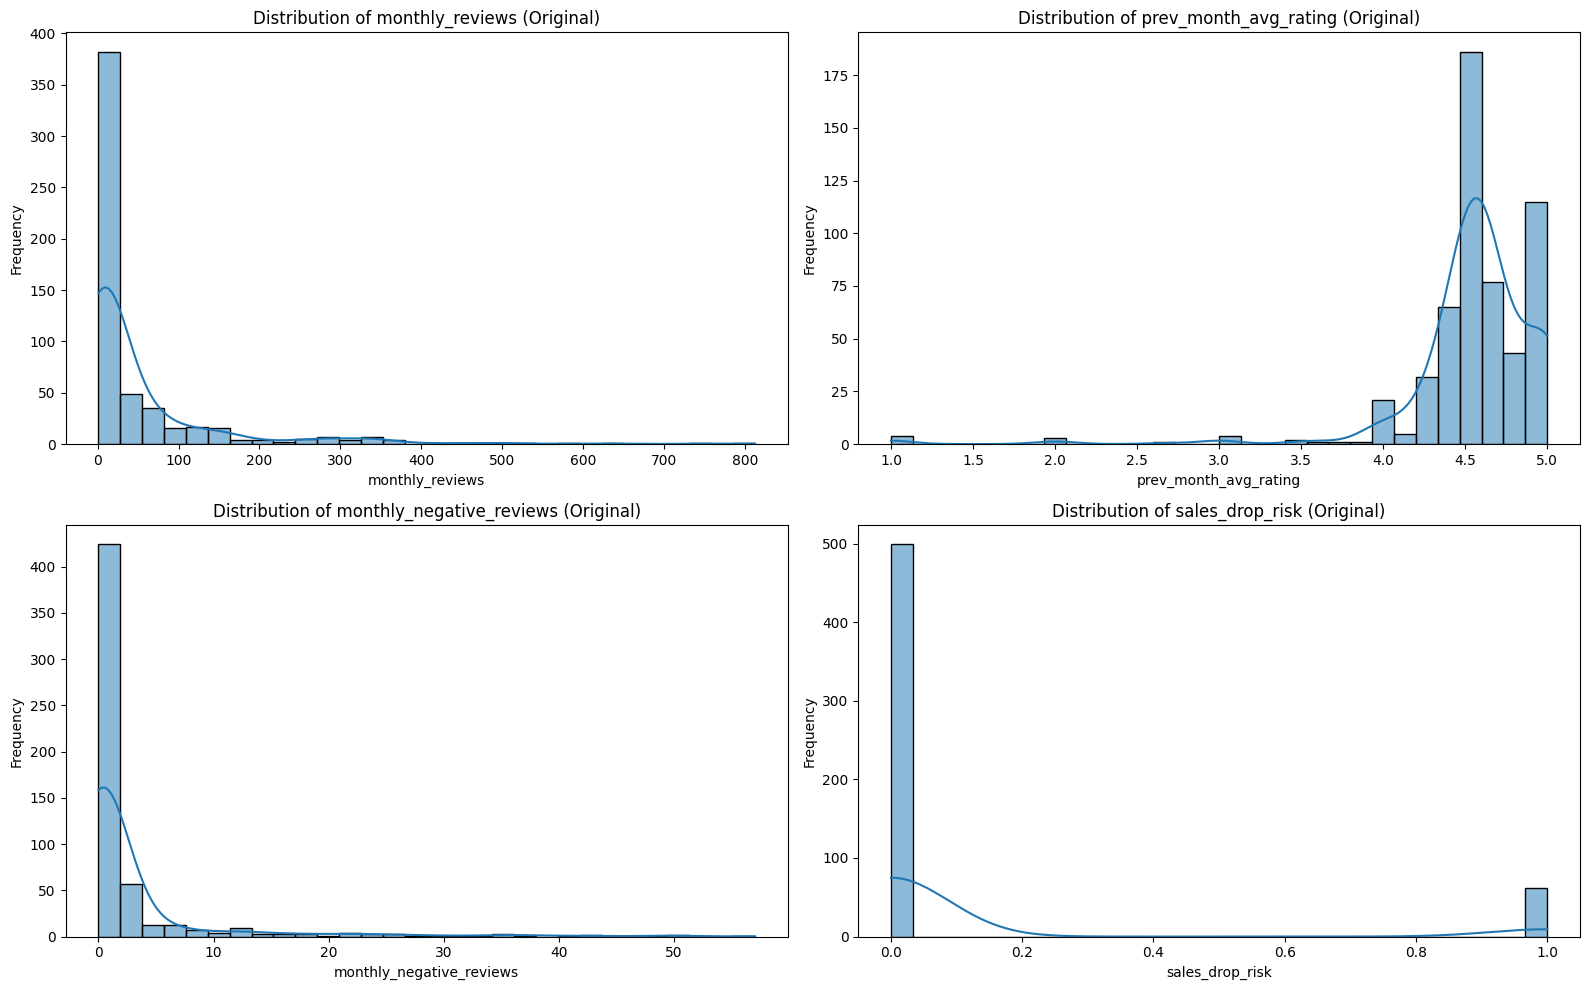

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to visualize (assuming these are numerical and present in both DataFrames)
# 'monthly_avg_rating' was removed to prevent data leakage, so using 'prev_month_avg_rating' instead.
plot_cols = ['monthly_reviews', 'prev_month_avg_rating', 'monthly_negative_reviews', 'sales_drop_risk']

print("Histograms for final_dataset (Original Data)")
plt.figure(figsize=(16, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(final_dataset[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (Original)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Histograms for final_dataset_ohe (One-Hot Encoded Data - numerical columns)


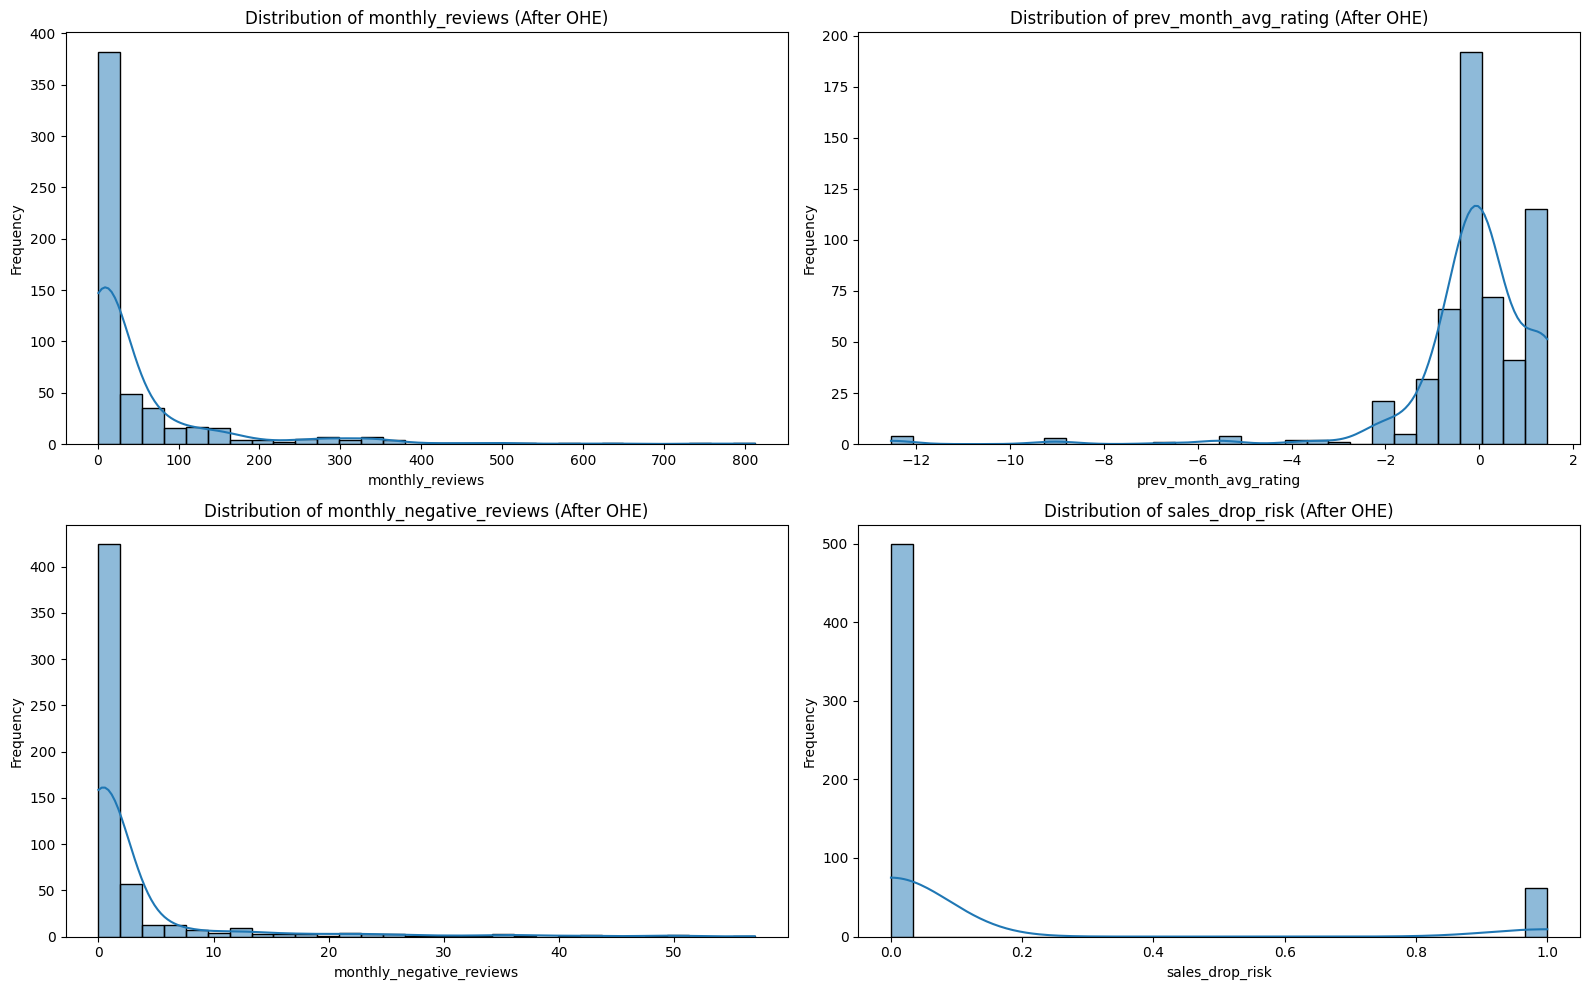

In [ ]:
print("Histograms for final_dataset_ohe (One-Hot Encoded Data - numerical columns)")
plt.figure(figsize=(16, 10))
for i, col in enumerate(plot_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(final_dataset_ohe[col], kde=True, bins=30)
    plt.title(f'Distribution of {col} (After OHE)')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


Al observar estos histogramas, notarás que las distribuciones de las variables numéricas clave (`monthly_reviews`, `monthly_avg_rating`, `monthly_negative_reviews`, `sales_drop_risk`) son idénticas en `final_dataset` y `final_dataset_ohe`. Esto es esperado, ya que la One-Hot Encoding solo afecta a las variables categóricas, creando nuevas columnas binarias sin alterar las distribuciones de las variables numéricas preexistentes.

#**Feature engineering específica del dominio**

In [ ]:
import numpy as np
import pandas as pd

# =========================
# Feature engineering sin fuga de datos
# =========================

required_cols = ["monthly_negative_rate", "monthly_avg_helpful"]
missing_cols = [col for col in required_cols if col not in X_train_ohe.columns]

if missing_cols:
    raise KeyError(f"Faltan columnas requeridas para feature engineering: {missing_cols}")

print("ANTES DE CREAR LA FEATURE")
print("Shape train:", X_train_ohe.shape)
print("Shape test:", X_test_ohe.shape)

# Crear la feature continua en train y test usando solo columnas de cada particion.
X_train_ohe_fe = X_train_ohe.copy()
X_test_ohe_fe = X_test_ohe.copy()

# Fix: Ensure monthly_avg_helpful and monthly_negative_rate are purely numeric
# by converting to numeric, coercing errors to NaN, and filling NaN with 0.
# Then, ensure monthly_avg_helpful values are > -1 before applying np.log1p
# This prevents log(0) or log(negative numbers) and addresses the TypeError.

# Process training data
monthly_avg_helpful_train_clean = pd.to_numeric(X_train_ohe_fe["monthly_avg_helpful"], errors='coerce').fillna(0)
monthly_negative_rate_train_clean = pd.to_numeric(X_train_ohe_fe["monthly_negative_rate"], errors='coerce').fillna(0)

X_train_ohe_fe["negative_helpfulness_pressure"] = (
    monthly_negative_rate_train_clean *
    np.log1p(monthly_avg_helpful_train_clean.clip(lower=-0.99999))
)

# Process test data
monthly_avg_helpful_test_clean = pd.to_numeric(X_test_ohe_fe["monthly_avg_helpful"], errors='coerce').fillna(0)
monthly_negative_rate_test_clean = pd.to_numeric(X_test_ohe_fe["monthly_negative_rate"], errors='coerce').fillna(0)

X_test_ohe_fe["negative_helpfulness_pressure"] = (
    monthly_negative_rate_test_clean *
    np.log1p(monthly_avg_helpful_test_clean.clip(lower=-0.99999))
)

# El umbral del percentil 75 se aprende SOLO con train.
threshold_pressure = X_train_ohe_fe["negative_helpfulness_pressure"].quantile(0.75)

X_train_ohe_fe["high_negative_helpfulness_pressure"] = np.where(
    X_train_ohe_fe["negative_helpfulness_pressure"] > threshold_pressure,
    1,
    0
)

X_test_ohe_fe["high_negative_helpfulness_pressure"] = np.where(
    X_test_ohe_fe["negative_helpfulness_pressure"] > threshold_pressure,
    1,
    0
)

# Reconstruir dataset completo solo para exploracion/compatibilidad.
train_ohe_fe = X_train_ohe_fe.copy()
train_ohe_fe[target_col] = y_train

test_ohe_fe = X_test_ohe_fe.copy()
test_ohe_fe[target_col] = y_test

final_dataset_ohe = pd.concat([train_ohe_fe, test_ohe_fe], axis=0).sort_index()

print("DESPUES DE CREAR LA FEATURE")
print("Umbral percentil 75 aprendido en train:", threshold_pressure)
print("Shape train:", X_train_ohe_fe.shape)
print("Shape test:", X_test_ohe_fe.shape)
print("Shape final_dataset_ohe reconstruido:", final_dataset_ohe.shape)

display(
    final_dataset_ohe[
        [
            "monthly_negative_rate",
            "monthly_avg_helpful",
            "negative_helpfulness_pressure",
            "high_negative_helpfulness_pressure",
            "sales_drop_risk"
        ]
    ].head(10)
)

display(
    train_ohe_fe.groupby(target_col)[
        [
            "negative_helpfulness_pressure",
            "high_negative_helpfulness_pressure"
        ]
    ].mean()
)


ANTES DE CREAR LA FEATURE
Shape train: (448, 42)
Shape test: (113, 42)
DESPUES DE CREAR LA FEATURE
Umbral percentil 75 aprendido en train: 0.0
Shape train: (448, 44)
Shape test: (113, 44)
Shape final_dataset_ohe reconstruido: (561, 45)


,monthly_negative_rate,monthly_avg_helpful,negative_helpfulness_pressure,high_negative_helpfulness_pressure,sales_drop_risk
0,0.0,66.0,0.0,0,0
1,0.0,0.3,0.0,0,0
2,0.0,0.333333,0.0,0,0
3,0.0,0.0,0.0,0,0
4,0.0,0.0,0.0,0,0
5,1.144298,0.0,0.0,0,0
6,0.0,0.0,0.0,0,0
7,0.0,0.0,0.0,0,0
8,0.0,0.0,0.0,0,0
9,0.0,0.0,0.0,0,1


,negative_helpfulness_pressure,high_negative_helpfulness_pressure
sales_drop_risk,,
0,0.844097,0.170854
1,7.541316,0.260000


In [ ]:
display(final_dataset_ohe.head())

#**Selección de características**

##1. Metodo Filter

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# =========================
# Metodo Filter sin fuga de datos
# =========================

# Variables candidatas: solo numericas y excluyendo el target y 'monthly_reviews'.
filter_feature_cols = X_train_ohe_fe.select_dtypes(include=["number"]).columns.tolist()
filter_feature_cols = [col for col in filter_feature_cols if col != target_col and col != 'monthly_reviews']

X_train_filter_base = X_train_ohe_fe[filter_feature_cols]
X_test_filter_base = X_test_ohe_fe[filter_feature_cols]

# VarianceThreshold se ajusta SOLO con train y luego se aplica a test.
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_filter_base)

selected_numeric_cols = X_train_filter_base.columns[selector.get_support()].tolist()
removed_numeric_cols = X_train_filter_base.columns[~selector.get_support()].tolist()

X_train_filtered = pd.DataFrame(
    selector.transform(X_train_filter_base),
    columns=selected_numeric_cols,
    index=X_train_filter_base.index
)

X_test_filtered = pd.DataFrame(
    selector.transform(X_test_filter_base),
    columns=selected_numeric_cols,
    index=X_test_filter_base.index
)

# Add 'monthly_reviews' back to the filtered datasets since it was explicitly excluded from filtering
X_train_filtered['monthly_reviews'] = X_train_ohe_fe['monthly_reviews']
X_test_filtered['monthly_reviews'] = X_test_ohe_fe['monthly_reviews']

train_filtered = X_train_filtered.copy()
train_filtered[target_col] = y_train

test_filtered = X_test_filtered.copy()
test_filtered[target_col] = y_test

final_dataset_ohe_filtered = pd.concat([train_filtered, test_filtered], axis=0).sort_index()

# --- BEGIN MODIFICATION ---
# The following modification is being removed because 'monthly_reviews' is now explicitly
# excluded from RobustScaler in lEDnFIJlz4Vp. This means it (and other count columns if configured)
# will no longer be scaled and therefore will not produce negative or fractional values.
# The clipping was a workaround for display, which is no longer needed.
# original_count_cols = [
#     'monthly_reviews', 'monthly_negative_reviews', 'monthly_positive_reviews',
#     'monthly_not_recommended', 'total_reviews', 'negative_reviews',
#     'neutral_reviews', 'positive_reviews', 'not_recommended_count'
# ]
# existing_count_cols = [col for col in original_count_cols if col in final_dataset_ohe_filtered.columns]
# for col in existing_count_cols:
#     final_dataset_ohe_filtered[col] = final_dataset_ohe_filtered[col].round().astype(int).clip(lower=0)
# --- END MODIFICATION ---

print("Variables numericas seleccionadas (VarianceThreshold):")
print(selected_numeric_cols)
print("Variables numericas eliminadas por baja varianza:")
print(removed_numeric_cols)
print("Dataset base train:", X_train_filter_base.shape)
print("Dataset base test:", X_test_filter_base.shape)
print("Dataset filtrado train:", X_train_filtered.shape)
print("Dataset filtrado test:", X_test_filtered.shape)
print("Columnas removidas por baja varianza:", len(removed_numeric_cols))

display(final_dataset_ohe_filtered.head())

Variables numericas seleccionadas (VarianceThreshold):
['negative_helpfulness_pressure', 'high_negative_helpfulness_pressure']
Variables numericas eliminadas por baja varianza:
[]
Dataset base train: (448, 2)
Dataset base test: (113, 2)
Dataset filtrado train: (448, 3)
Dataset filtrado test: (113, 3)
Columnas removidas por baja varianza: 0


,negative_helpfulness_pressure,high_negative_helpfulness_pressure,monthly_reviews,sales_drop_risk
0,0.0,0.0,1,0
1,0.0,0.0,5,0
2,0.0,0.0,9,0
3,0.0,0.0,3,0
4,0.0,0.0,1,0


##Tabla con la varianza de cada variable

In [ ]:
variance_summary = pd.DataFrame({
    "variable": filter_feature_cols,
    "variance_train": selector.variances_,
    "selected": selector.get_support()
})

variance_summary["decision"] = np.where(
    variance_summary["selected"],
    "Seleccionada",
    "Eliminada por baja varianza"
)

variance_summary = variance_summary.sort_values(by="variance_train")

display(variance_summary)


,variable,variance_train,selected,decision
1,high_negative_helpfulness_pressure,0.148114,True,Seleccionada
0,negative_helpfulness_pressure,146.230572,True,Seleccionada


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_rfe.py:839: UserWarning: Found min_features_to_select=5 > n_features=3. There will be no feature selection and all features will be kept.
  warnings.warn(


Modelo utilizado: LogisticRegression
Metrica utilizada: f1
Cantidad final de variables: 3
Shape wrapper train: (448, 3)
Shape wrapper test: (113, 3)
Shape del dataset reconstruido (wrapper): (561, 4)


,negative_helpfulness_pressure,high_negative_helpfulness_pressure,monthly_reviews,sales_drop_risk
0,0.0,0.0,1,0
1,0.0,0.0,5,0
2,0.0,0.0,9,0
3,0.0,0.0,3,0
4,0.0,0.0,1,0


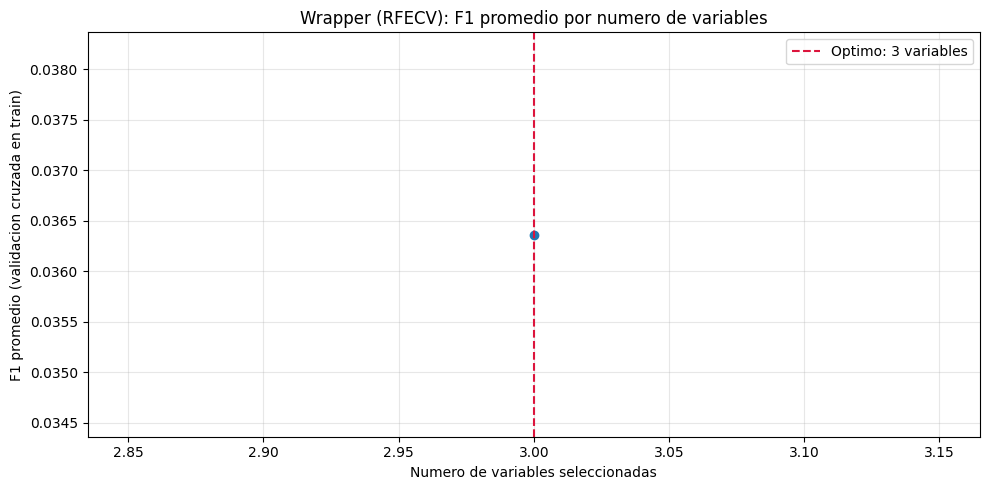

In [ ]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# =========================
# Wrapper Method (RFECV) sin fuga de datos
# =========================

# RFECV se ajusta SOLO con train. Internamente usa validacion cruzada solo dentro de train.
model = LogisticRegression(max_iter=2000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

selector_wrapper = RFECV(
    estimator=model,
    step=1,
    cv=cv,
    scoring="f1",
    min_features_to_select=5,
    n_jobs=-1
)

selector_wrapper.fit(X_train_filtered, y_train)

selected_features = X_train_filtered.columns[selector_wrapper.support_].tolist()

X_train_wrapper = X_train_filtered[selected_features].copy()
X_test_wrapper = X_test_filtered[selected_features].copy()

train_wrapper = X_train_wrapper.copy()
train_wrapper[target_col] = y_train

test_wrapper = X_test_wrapper.copy()
test_wrapper[target_col] = y_test

final_dataset_ohe_wrapper = pd.concat([train_wrapper, test_wrapper], axis=0).sort_index()

print("Modelo utilizado:", model.__class__.__name__)
print("Metrica utilizada:", selector_wrapper.scoring)
print("Cantidad final de variables:", len(selected_features))
print("Shape wrapper train:", X_train_wrapper.shape)
print("Shape wrapper test:", X_test_wrapper.shape)
print("Shape del dataset reconstruido (wrapper):", final_dataset_ohe_wrapper.shape)

display(final_dataset_ohe_wrapper.head())

cv_scores = selector_wrapper.cv_results_["mean_test_score"]
n_features = selector_wrapper.cv_results_.get("n_features")
if n_features is None:
    n_features = range(1, len(cv_scores) + 1)

plt.figure(figsize=(10, 5))
plt.plot(n_features, cv_scores, marker="o", linewidth=2)
plt.axvline(selector_wrapper.n_features_, color="crimson", linestyle="--",
            label=f"Optimo: {selector_wrapper.n_features_} variables")
plt.title("Wrapper (RFECV): F1 promedio por numero de variables")
plt.xlabel("Numero de variables seleccionadas")
plt.ylabel("F1 promedio (validacion cruzada en train)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Reduccion dimensional con PCA sin fuga de datos

PCA se ajusta solo con `X_train` y despues transforma `X_test` con el mismo escalador y los mismos componentes. El numero de componentes se decide usando la varianza explicada acumulada en entrenamiento.


Dimensiones originales train: 3
Dimensiones finales PCA (95% varianza train): 3
Varianza explicada acumulada en train con 3 componentes: 1.0000
Shape PCA train: (448, 3)
Shape PCA test: (113, 3)
Shape dataset reconstruido PCA: (561, 4)


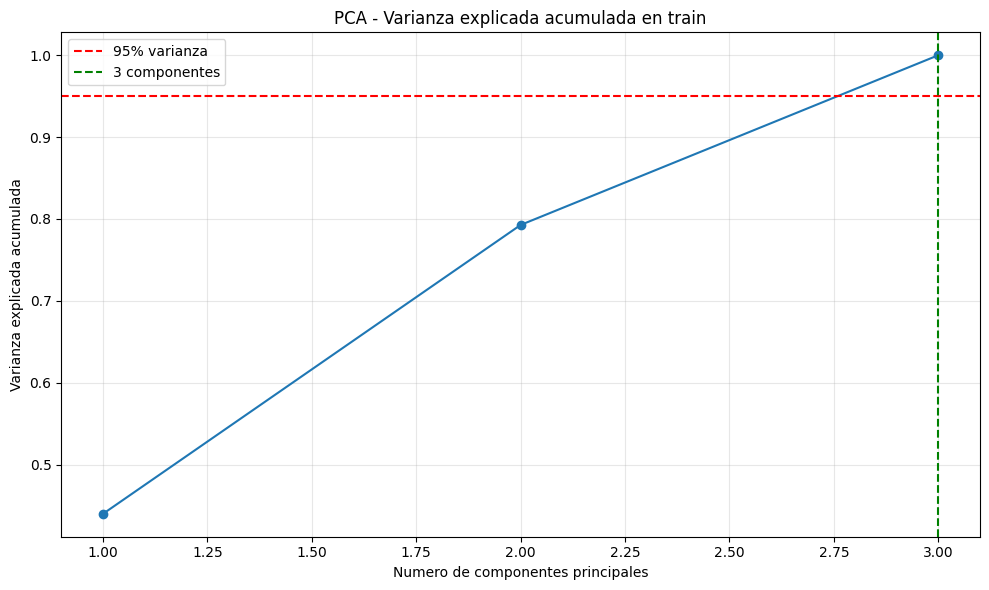

,PC1,PC2,PC3,sales_drop_risk
0,-0.598349,-0.350161,-0.015010,0
1,-0.584059,-0.317966,-0.033263,0
2,-0.569770,-0.285771,-0.051516,0
3,-0.591204,-0.334063,-0.024137,0
4,-0.598349,-0.350161,-0.015010,0


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# =========================
# PCA sin fuga de datos
# =========================

# Usamos las variables despues del filtro de baja varianza.
# Si se prefiere PCA despues del wrapper, cambiar a X_train_wrapper / X_test_wrapper.
X_train_pca_base = X_train_filtered.copy()
X_test_pca_base = X_test_filtered.copy()

# Escalado para PCA: se ajusta SOLO con train.
pca_scaler = StandardScaler()
X_train_scaled = pca_scaler.fit_transform(X_train_pca_base)
X_test_scaled = pca_scaler.transform(X_test_pca_base)

# PCA completo ajustado SOLO con train para analizar varianza explicada.
pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

# Numero minimo de componentes para conservar al menos 95% de varianza en train.
n_components_95 = np.argmax(cumulative_explained_variance >= 0.95) + 1

# PCA final ajustado SOLO con train y aplicado a train/test.
pca_final = PCA(n_components=n_components_95, random_state=42)
X_train_pca_array = pca_final.fit_transform(X_train_scaled)
X_test_pca_array = pca_final.transform(X_test_scaled)

pca_columns = [f"PC{i+1}" for i in range(n_components_95)]
X_train_pca = pd.DataFrame(X_train_pca_array, columns=pca_columns, index=X_train_pca_base.index)
X_test_pca = pd.DataFrame(X_test_pca_array, columns=pca_columns, index=X_test_pca_base.index)

train_pca = X_train_pca.copy()
train_pca[target_col] = y_train

test_pca = X_test_pca.copy()
test_pca[target_col] = y_test

final_dataset_ohe_pca = pd.concat([train_pca, test_pca], axis=0).sort_index()

original_dims = X_train_pca_base.shape[1]
final_dims = X_train_pca.shape[1]

print(f"Dimensiones originales train: {original_dims}")
print(f"Dimensiones finales PCA (95% varianza train): {final_dims}")
print(f"Varianza explicada acumulada en train con {final_dims} componentes: {pca_final.explained_variance_ratio_.sum():.4f}")
print("Shape PCA train:", X_train_pca.shape)
print("Shape PCA test:", X_test_pca.shape)
print("Shape dataset reconstruido PCA:", final_dataset_ohe_pca.shape)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} componentes')
plt.title('PCA - Varianza explicada acumulada en train')
plt.xlabel('Numero de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(final_dataset_ohe_pca.head())


El analisis mediante PCA ahora se realiza sin fuga de datos: `StandardScaler`, el calculo de varianza explicada y los componentes principales se ajustan solo con `X_train`. Luego `X_test` se transforma con esos mismos parametros.

Para modelado quedan disponibles `X_train_filtered` / `X_test_filtered`, `X_train_wrapper` / `X_test_wrapper` y `X_train_pca` / `X_test_pca`, junto con `y_train` / `y_test`.
